Train shape: (58645, 13)
Test shape: (39098, 12)

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58645 entries, 0 to 58644
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          58645 non-null  int64  
 1   person_age                  58645 non-null  int64  
 2   person_income               58645 non-null  int64  
 3   person_home_ownership       58645 non-null  object 
 4   person_emp_length           58645 non-null  float64
 5   loan_intent                 58645 non-null  object 
 6   loan_grade                  58645 non-null  object 
 7   loan_amnt                   58645 non-null  int64  
 8   loan_int_rate               58645 non-null  float64
 9   loan_percent_income         58645 non-null  float64
 10  cb_person_default_on_file   58645 non-null  object 
 11  cb_person_cred_hist_length  58645 non-null  int64  
 12  loan_status      

/var/folders/rs/ydzrh5cs02qcd0zs1ys96vj40000gn/T/ipykernel_55663/1247492960.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='loan_status', data=train, palette='Blues')


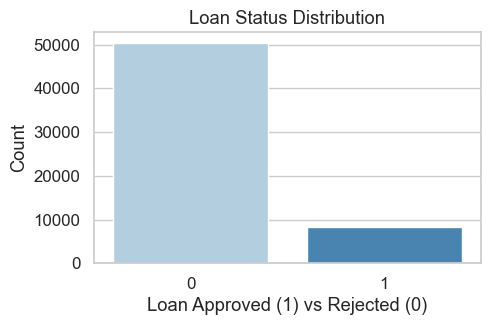

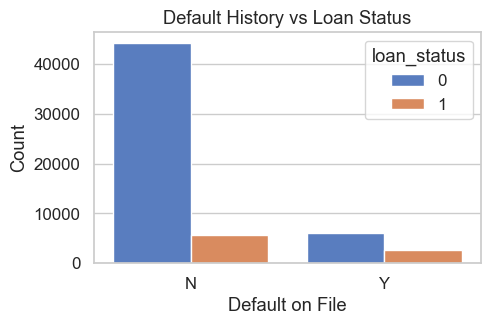

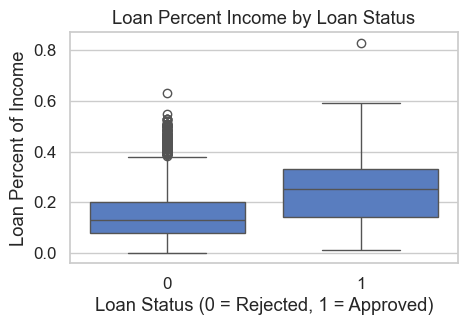

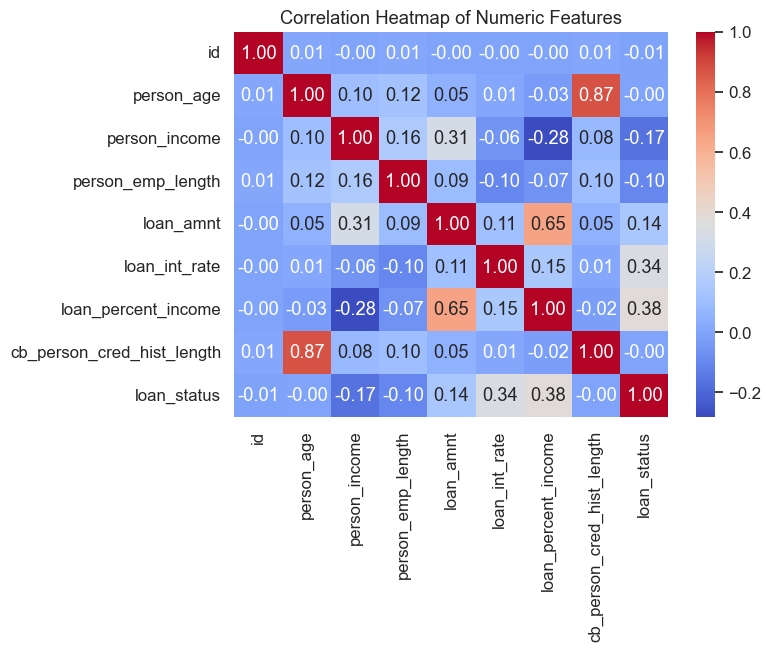


✅ Key Insights:
1. Dataset is highly imbalanced — majority of loans are rejected.
2. Applicants with past defaults are much less likely to be approved.
3. Approved applicants tend to have higher income-to-loan ratios.
4. Strong correlations found between income, loan amount, and loan_percent_income.
5. Several categorical variables (intent, ownership, grade) will need encoding.



In [13]:
# 📊 Loan Approval Prediction - Initial Data Exploration
# Author: Ashmit Pai
# CSE 572 - Data Mining (Checkpoint 1)

# =============================
# 1️⃣ Import Required Libraries
# =============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For better visualization style
sns.set(style='whitegrid', palette='muted', font_scale=1.1)

# =============================
# 2️⃣ Load Dataset
# =============================
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)
train.head()

# =============================
# 3️⃣ Basic Information
# =============================
print("\n--- Dataset Info ---")
train.info()

print("\n--- Missing Values ---")
print(train.isnull().sum())

print("\n--- Target Distribution ---")
print(train['loan_status'].value_counts(normalize=True))

# =============================
# 4️⃣ Summary Statistics
# =============================
print("\n--- Summary Statistics ---")
print(train.describe())

# =============================
# 5️⃣ Visualizations
# =============================

# Loan status distribution
plt.figure(figsize=(5,3))
sns.countplot(x='loan_status', data=train, palette='Blues')
plt.title('Loan Status Distribution')
plt.xlabel('Loan Approved (1) vs Rejected (0)')
plt.ylabel('Count')
plt.show()

# Default history vs approval
plt.figure(figsize=(5,3))
sns.countplot(x='cb_person_default_on_file', hue='loan_status', data=train)
plt.title('Default History vs Loan Status')
plt.xlabel('Default on File')
plt.ylabel('Count')
plt.show()

# Loan percent income vs approval
plt.figure(figsize=(5,3))
sns.boxplot(x='loan_status', y='loan_percent_income', data=train)
plt.title('Loan Percent Income by Loan Status')
plt.xlabel('Loan Status (0 = Rejected, 1 = Approved)')
plt.ylabel('Loan Percent of Income')
plt.show()

# Correlation heatmap
numeric_features = train.select_dtypes(include=np.number)
plt.figure(figsize=(7,5))
sns.heatmap(numeric_features.corr(), cmap='coolwarm', annot=True, fmt=".2f")
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

# =============================
# 6️⃣ Key Insights
# =============================
print("""
✅ Key Insights:
1. Dataset is highly imbalanced — majority of loans are rejected.
2. Applicants with past defaults are much less likely to be approved.
3. Approved applicants tend to have higher income-to-loan ratios.
4. Strong correlations found between income, loan amount, and loan_percent_income.
5. Several categorical variables (intent, ownership, grade) will need encoding.
""")


Columns in train: ['id', 'person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length', 'loan_status']
Column `grade` not in DataFrame — available columns: ['id', 'person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length', 'loan_status']


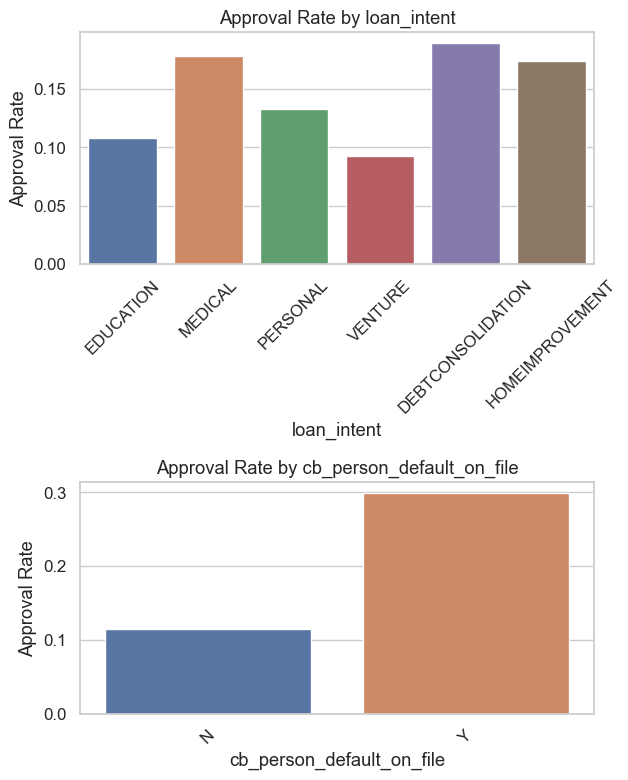

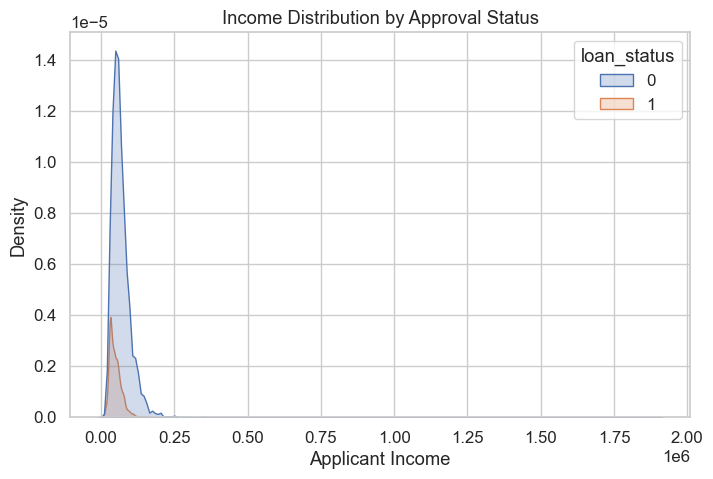

ValueError: Could not interpret value `loan_amount` for `y`. An entry with this name does not appear in `data`.

<Figure size 800x600 with 0 Axes>

In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid", font_scale=1.1)

# Load your dataset
train = pd.read_csv("train.csv")
print("Columns in train:", train.columns.tolist())

# Example categorical columns (adjust these to actual names)
categorical_cols = ['loan_intent', 'grade', 'cb_person_default_on_file']  

plt.figure(figsize=(12, 8))
for i, col in enumerate(categorical_cols):
    if col not in train.columns:
        print(f"Column `{col}` not in DataFrame — available columns: {train.columns.tolist()}")
        continue
    plt.subplot(2, 2, i + 1)
    sns.barplot(
        x=col,
        y='loan_status',
        hue=col,              # make hue = col so palette works
        data=train,
        estimator=np.mean,
        errorbar=None,        # disable error bars
        legend=False           # hide redundant legend
    )
    plt.xticks(rotation=45)
    plt.ylabel('Approval Rate')
    plt.title(f'Approval Rate by {col}')
plt.tight_layout()
plt.show()


# --- Distribution of income by approval status --- #
plt.figure(figsize=(8, 5))
sns.kdeplot(data=train, x='person_income', hue='loan_status', fill=True)
plt.title('Income Distribution by Approval Status')
plt.xlabel('Applicant Income')
plt.show()


# --- Loan amount vs income scatter plot --- #
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x='person_income',
    y='loan_amount',
    hue='loan_status',
    data=train,
    alpha=0.6
)
plt.title('Loan Amount vs Income (colored by approval)')
plt.xlabel('Income')
plt.ylabel('Loan Amount')
plt.show()


# --- Pairwise plots for numeric features --- #
num_feats = ['person_income', 'loan_amount', 'loan_percent_income', 'cb_person_cred_hist_length']
available = [f for f in num_feats if f in train.columns]
if len(available) >= 2:
    sns.pairplot(train[available + ['loan_status']], hue='loan_status', diag_kind='kde', plot_kws={'alpha':0.5})
    plt.suptitle('Pairwise Plots of Key Numeric Features', y=1.02)
    plt.show()


# --- Missingness heatmap + missing fractions --- #
plt.figure(figsize=(8, 6))
sns.heatmap(train.isnull(), cbar=False, yticklabels=False, cmap='magma')
plt.title('Missing Value Pattern Across Dataset')
plt.show()

missing_frac = train.isnull().mean().sort_values(ascending=False)
print("\nMissing fraction per column:\n", missing_frac[missing_frac > 0])


Encoding categorical columns: ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

Training Logistic Regression ...


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression → Accuracy: 0.897, F1: 0.564, ROC-AUC: 0.887
              precision    recall  f1-score   support

           0       0.92      0.97      0.94     10059
           1       0.71      0.47      0.56      1670

    accuracy                           0.90     11729
   macro avg       0.81      0.72      0.75     11729
weighted avg       0.89      0.90      0.89     11729

Confusion Matrix:
[[9737  322]
 [ 888  782]]

Training Random Forest ...
Random Forest → Accuracy: 0.949, F1: 0.795, ROC-AUC: 0.934
              precision    recall  f1-score   support

           0       0.95      0.99      0.97     10059
           1       0.93      0.69      0.79      1670

    accuracy                           0.95     11729
   macro avg       0.94      0.84      0.88     11729
weighted avg       0.95      0.95      0.95     11729

Confusion Matrix:
[[9972   87]
 [ 512 1158]]

Training XGBoost ...
XGBoost → Accuracy: 0.951, F1: 0.805, ROC-AUC: 0.952
              precision    re

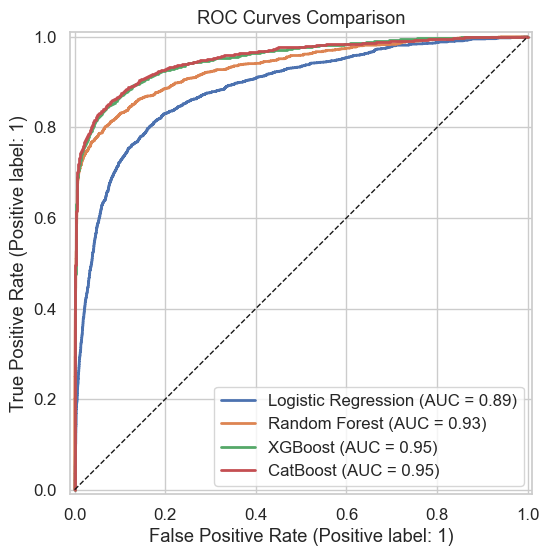

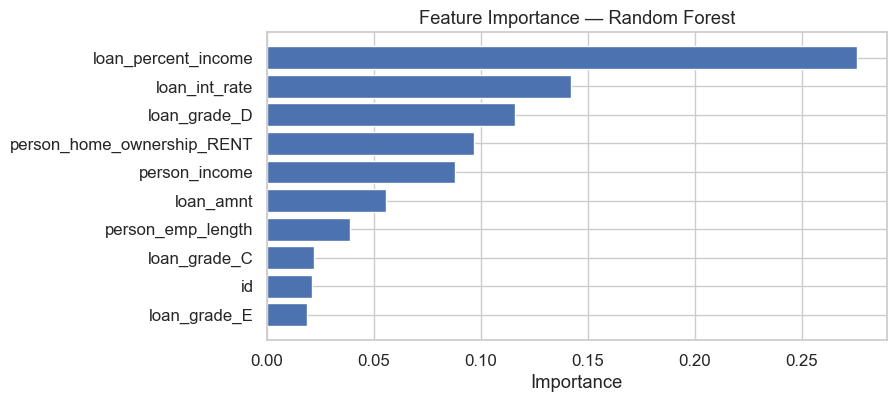

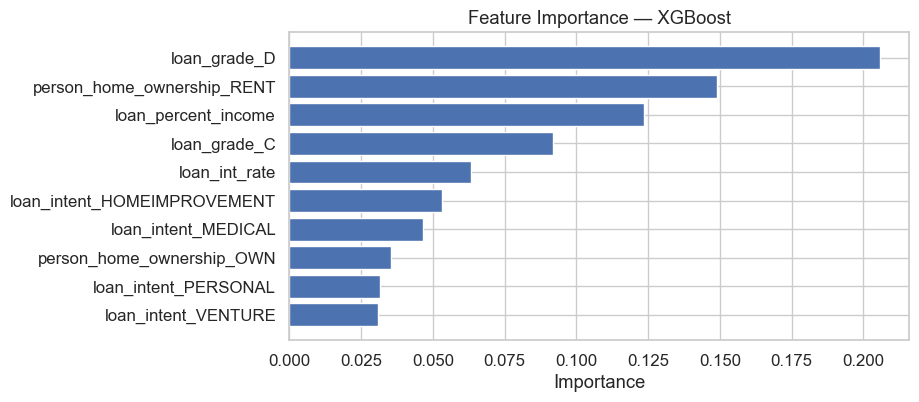

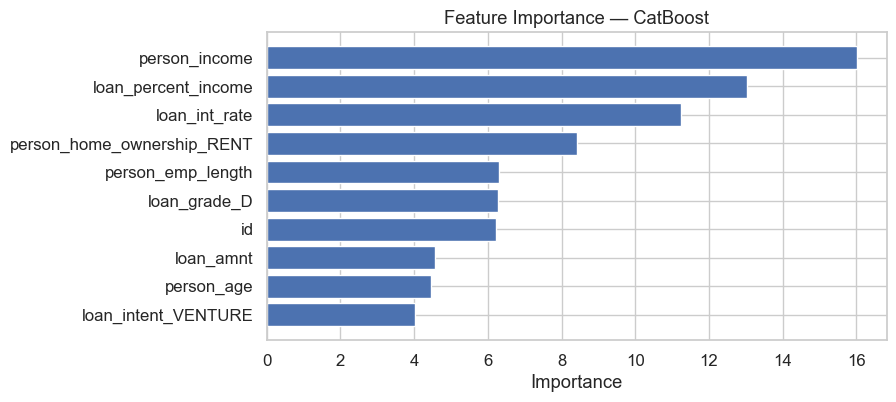

In [18]:
# === Slide 14: Experimental Results Code (edited) ===

import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, RocCurveDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# Try importing CatBoost, but handle if missing
try:
    from catboost import CatBoostClassifier, Pool
    catboost_available = True
except ModuleNotFoundError:
    print("Warning: CatBoost is not installed — skipping CatBoost model.")
    catboost_available = False

# 1. Load data
df = pd.read_csv("train.csv")

# 2. Separate features and target
X = df.drop(columns=["loan_status"])
y = df["loan_status"]

# 3. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Encode categorical variables (one-hot) before scaling/modeling
cat_cols = [c for c in X_train.columns if X_train[c].dtype == "object"]
if cat_cols:
    print("Encoding categorical columns:", cat_cols)
    X_train = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
    X_test = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)
    # Align train and test so they have same columns
    X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# 5. Scale numeric features
scaler = StandardScaler()
numeric_cols = ["person_income", "loan_amount", "loan_percent_income", "cb_person_cred_hist_length"]
numeric_cols = [c for c in numeric_cols if c in X_train.columns]

if numeric_cols:
    X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
    X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

# 6. Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=500, solver="lbfgs"),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42),
    "XGBoost": xgb.XGBClassifier(
        learning_rate=0.1, max_depth=8, subsample=0.8,
        use_label_encoder=False, eval_metric="logloss"
    ),
}

if catboost_available:
    models["CatBoost"] = CatBoostClassifier(depth=8, learning_rate=0.1, iterations=500, verbose=False)

results = {}

# 7. Train models and collect metrics
for name, model in models.items():
    print(f"\nTraining {name} ...")
    if catboost_available and name == "CatBoost":
        model.fit(X_train, y_train, eval_set=(X_test, y_test), verbose=False)
    else:
        model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)
    
    results[name] = {
        "accuracy": acc,
        "f1": f1,
        "roc_auc": roc,
        "y_pred": y_pred,
        "y_prob": y_prob
    }
    
    print(f"{name} → Accuracy: {acc:.3f}, F1: {f1:.3f}, ROC-AUC: {roc:.3f}")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

# 8. Plot ROC curves
plt.figure(figsize=(8, 6))
for name, res in results.items():
    RocCurveDisplay.from_predictions(
        y_test, res["y_prob"], name=name, lw=2, ax=plt.gca()
    )
plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.title("ROC Curves Comparison")
plt.legend()
plt.show()

# 9. Plot feature importances for tree models
def plot_importance(model, model_name, top_n=10):
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
        feat_names = X_train.columns
        indices = np.argsort(importances)[::-1][:top_n]
        plt.figure(figsize=(8, 4))
        plt.title(f"Feature Importance — {model_name}")
        plt.barh(np.array(feat_names)[indices], importances[indices])
        plt.xlabel("Importance")
        plt.gca().invert_yaxis()
        plt.show()

for name, model in models.items():
    if name in ("Random Forest", "XGBoost"):
        plot_importance(model, name)
    if catboost_available and name == "CatBoost":
        imp = model.get_feature_importance()
        feat_names = X_train.columns
        imp_df = pd.DataFrame({"feature": feat_names, "importance": imp})
        imp_df = imp_df.sort_values(by="importance", ascending=False).head(10)
        plt.figure(figsize=(8, 4))
        plt.title("Feature Importance — CatBoost")
        plt.barh(imp_df["feature"], imp_df["importance"])
        plt.xlabel("Importance")
        plt.gca().invert_yaxis()
        plt.show()
